## Model Evaluation - K-Means Clustering

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from scipy.stats import mode

### Load Dataset

In [2]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

### Features and Target

In [3]:
X = df.drop("default_12m", axis=1)
y = df["default_12m"]

### Split Data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Standardize Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train K-Means

In [7]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Predict Clusters

In [8]:
train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

### Map Cluster labels to actual class labels

In [9]:
mapping = {}

for cluster in range(2):
    mask = (train_clusters == cluster)
    if mask.sum() > 0:
        mapping[cluster] = mode(y_train[mask], keepdims=True).mode[0]

### Convert Cluster label to predicted class labels

In [10]:
y_pred = [mapping[c] for c in test_clusters]

### Evalauation

In [11]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9231851851851852
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Confusion Matrix
[[24926     0]
 [ 2074     0]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     24926
           1       0.00      0.00      0.00      2074

    accuracy                           0.92     27000
   macro avg       0.46      0.50      0.48     27000
weighted avg       0.85      0.92      0.89     27000



C:\Users\DHARVIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DHARVIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DHARVIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DHARVIN\anaconda3\Lib

### Plot Confusion Matrix

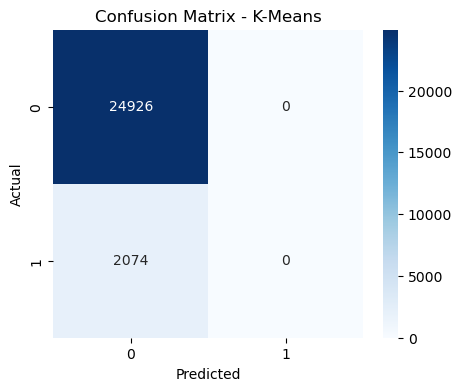

In [12]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - K-Means")
plt.show()

### Result Table

In [13]:
results = pd.DataFrame({
    "Model": ["K-Means"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1-score": [f1_score(y_test, y_pred)]
})

print(results)

     Model  Accuracy  Precision  Recall  F1-score
0  K-Means  0.923185        0.0     0.0       0.0


C:\Users\DHARVIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Plot Metrices

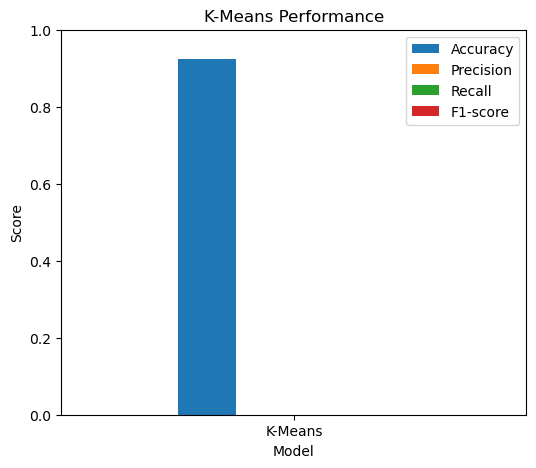

In [14]:
results.set_index("Model").plot(kind="bar", figsize=(6,5))
plt.title("K-Means Performance")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.show()

In [15]:
print(confusion_matrix(y_test, y_pred))

[[24926     0]
 [ 2074     0]]
